In [1]:
import numpy as np
import numpy as np
import pandas as pd

school_margin_df = pd.read_csv("../data/processed/final_resale_data_with_names.csv")
school_margin_df['Date'] = pd.to_datetime(school_margin_df['Date'])

In [2]:
import pandas as pd

def add_categorical_dummies(df, categorical_cols):
    dummies = pd.get_dummies(
        df[categorical_cols].astype('category'),
        prefix=categorical_cols,
        drop_first=True,
        dtype=float
    )
    out = pd.concat(
        [df.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )
    return out, dummies.columns.tolist()

def clean_label(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
        .str.strip('_')
    )

def bucket_n_level(series):
    s = pd.to_numeric(series, errors='coerce')
    out = pd.Series(pd.NA, index=series.index, dtype='object')
    out.loc[s == 0] = '0'
    out.loc[s == 1] = '1'
    out.loc[s >= 2] = '2plus'
    return out


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_monthly_log_price_and_gap(
    df,
    title,
    date_col='Date',
    price_col='resale_price',
    treated_col='treated',
    policy_start='2021-10-01',
):
    plot_df = df.copy()
    plot_df['year_month'] = plot_df[date_col].dt.to_period('M').astype(str)
    plot_df['log_price'] = np.log(plot_df[price_col])

    monthly = (
        plot_df
        .groupby(['year_month', treated_col], as_index=False)['log_price']
        .mean()
        .sort_values('year_month')
    )

    treated_ts = monthly[monthly[treated_col] == 1].copy()
    control_ts = monthly[monthly[treated_col] == 0].copy()

    months = sorted(monthly['year_month'].unique())
    xpos = np.arange(len(months))

    treated_y = treated_ts.set_index('year_month').reindex(months)['log_price']
    control_y = control_ts.set_index('year_month').reindex(months)['log_price']
    gap = treated_y - control_y

    boundary = None
    if policy_start[:7] in months:
        boundary = months.index(policy_start[:7]) - 0.5

    # Plot 1: levels
    plt.figure(figsize=(12, 5))
    plt.plot(xpos, control_y, marker='o', linewidth=2, label='Control')
    plt.plot(xpos, treated_y, marker='o', linewidth=2, label='Treated')

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Mean log resale price')
    plt.title(f'{title}\nMonthly log-price trends')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: treated - control gap
    plt.figure(figsize=(12, 4))
    plt.plot(xpos, gap, marker='o', linewidth=2, color='darkgreen')

    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Treated - Control log price')
    plt.title(f'{title}\nMonthly treated-control gap')
    if boundary is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()


In [4]:
# DiD sample construction):
# - Restrict transactions to pre window (through 2021-08-31) and post window (from 2021-10-01); Sep 2021 omitted (Policy was implemented in the middle of september).
# - For each row, "pre" school counts using centroid proximity; "post" counts use polygon-based proximity (same split date).
# - Normal-school counts = total schools minus good-school counts in each distance band.
# - delta_normal_schools_0_1km = post minus pre in 0–1 km; keep only rows with delta in {0, 1}.
# - Require good-school counts unchanged pre→post in 0–1 km and 1–2 km so normal-school moves are not confounded
#   by reclassification of good schools under the new measure.
# - treated = 1 if delta_normal_schools_0_1km == 1, else 0 (controls: delta == 0 under the same filters).
# - Adds year_quarter, log_price, flat_type_clean; prints counts by treated × period.
pre_start  = pd.Timestamp('2018-09-01')
pre_end    = pd.Timestamp('2021-08-31')
post_start = pd.Timestamp('2021-10-01')
post_end   = pd.Timestamp('2023-03-31')

margin_new = school_margin_df[
    ((school_margin_df['Date'] >= pre_start) & (school_margin_df['Date'] <= pre_end)) |
    ((school_margin_df['Date'] >= post_start) & (school_margin_df['Date'] <= post_end))
].copy()

margin_new['period'] = np.where(margin_new['Date'] >= post_start, 'post', 'pre')
margin_new['post'] = (margin_new['period'] == 'post').astype(int)

margin_new['pre_num_good_schools_0_1km']  = margin_new['num_good_schools_0_1km_xy']
margin_new['post_num_good_schools_0_1km'] = margin_new['num_good_schools_0_1km_polygon']
margin_new['pre_num_good_schools_1_2km']  = margin_new['num_good_schools_1_2km_xy']
margin_new['post_num_good_schools_1_2km'] = margin_new['num_good_schools_1_2km_polygon']
margin_new['pre_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_xy']
margin_new['pre_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_xy']
margin_new['post_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_polygon']
margin_new['post_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_polygon']
margin_new['pre_num_good_schools_0_1km_bin'] = bucket_n_level(margin_new['pre_num_good_schools_0_1km'])
margin_new['pre_num_good_schools_1_2km_bin'] = bucket_n_level(margin_new['pre_num_good_schools_1_2km'])

margin_new['pre_num_good_schools_0_2km']  = margin_new['pre_num_good_schools_0_1km'] + margin_new['pre_num_good_schools_1_2km']
margin_new['post_num_good_schools_0_2km'] = margin_new['post_num_good_schools_0_1km'] + margin_new['post_num_good_schools_1_2km']

margin_new['pre_num_schools_0_1km']  = margin_new['num_schools_0_1km_xy']
margin_new['post_num_schools_0_1km'] = margin_new['num_schools_0_1km_polygon']
margin_new['pre_num_schools_1_2km']  = margin_new['num_schools_1_2km_xy']
margin_new['post_num_schools_1_2km'] = margin_new['num_schools_1_2km_polygon']

margin_new['pre_num_schools_0_2km']  = margin_new['pre_num_schools_0_1km'] + margin_new['pre_num_schools_1_2km']
margin_new['post_num_schools_0_2km'] = margin_new['post_num_schools_0_1km'] + margin_new['post_num_schools_1_2km']

margin_new['pre_num_normal_schools_0_1km'] = (
    margin_new['pre_num_schools_0_1km'] - margin_new['pre_num_good_schools_0_1km']
)
margin_new['post_num_normal_schools_0_1km'] = (
    margin_new['post_num_schools_0_1km'] - margin_new['post_num_good_schools_0_1km']
)
margin_new['pre_num_normal_schools_1_2km'] = (
    margin_new['pre_num_schools_1_2km'] - margin_new['pre_num_good_schools_1_2km']
)
margin_new['post_num_normal_schools_1_2km'] = (
    margin_new['post_num_schools_1_2km'] - margin_new['post_num_good_schools_1_2km']
)
margin_new['pre_num_normal_schools_0_2km'] = (
    margin_new['pre_num_schools_0_2km'] - margin_new['pre_num_good_schools_0_2km']
)
margin_new['post_num_normal_schools_0_2km'] = (
    margin_new['post_num_schools_0_2km'] - margin_new['post_num_good_schools_0_2km']
)

margin_new['delta_normal_schools_0_1km'] = margin_new['post_num_normal_schools_0_1km'] - margin_new['pre_num_normal_schools_0_1km']  #changed_for_normalschool

did_01x_new = margin_new[
    (margin_new['delta_normal_schools_0_1km'].isin([0, 1])) &  #changed_for_normalschool ensure treated units only have 0->1 change in normal schools within 1km
    (margin_new['pre_num_good_schools_0_1km'] == margin_new['post_num_good_schools_0_1km']) &  #changed_for_normalschool ensure no change in number of good schools within 1km
    (margin_new['pre_num_good_schools_1_2km'] == margin_new['post_num_good_schools_1_2km']) #changed_for_normalschool ensure no change in number of good schools within 1-2km

].copy()

did_01x_new['treated'] = (did_01x_new['delta_normal_schools_0_1km'] == 1).astype(int)  #changed_for_normalschool
did_01x_new['year_quarter'] = did_01x_new['Date'].dt.to_period('Q').astype(str)
did_01x_new['log_price'] = np.log(did_01x_new['resale_price'])
did_01x_new['flat_type_clean'] = clean_label(did_01x_new['flat_type'])

print("Sample size by treated / period:")
print(did_01x_new.groupby(['treated', 'period']).size())


Sample size by treated / period:
treated  period
0        post      23946
         pre       41526
1        post       9328
         pre       17204
dtype: int64


In [93]:
# Check if treated and control differ systematically on observables
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km'
]

print(
    did_01x_new.groupby('treated')[balance_cols]
    .mean()
    .T
    .assign(diff=lambda d: d[1] - d[0])
)

treated                                0           1       diff
floor_area_sqm                 96.025577   92.109621  -3.915957
remaining_lease               879.483061  823.506938 -55.976123
num_unique_mrt_lines            1.170014    1.227105   0.057090
num_nearby_malls                1.469663    1.334875  -0.134787
pre_num_good_schools_1_2km      0.638196    1.660500   1.022304
pre_num_normal_schools_0_1km    2.687324    2.343663  -0.343660


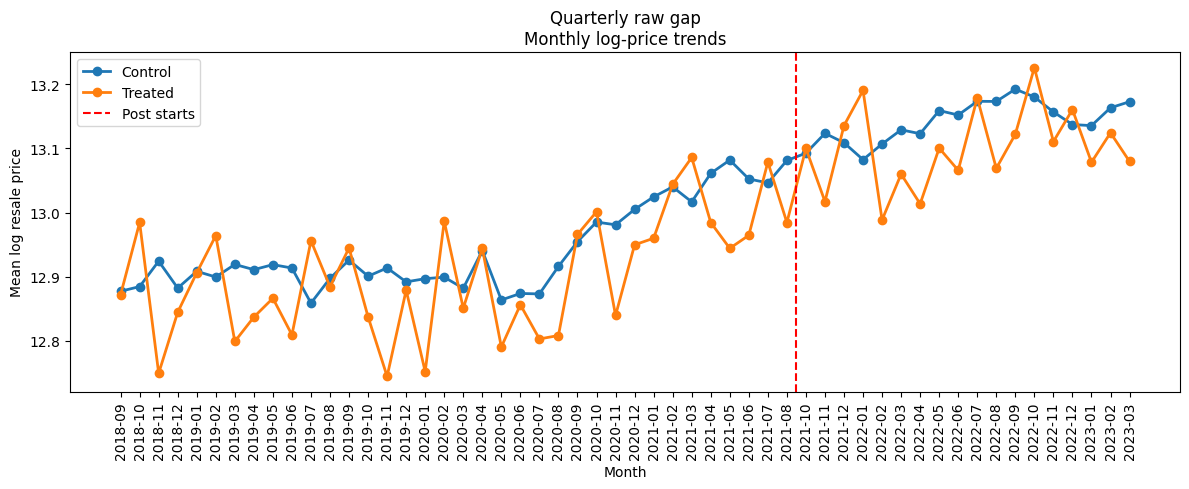

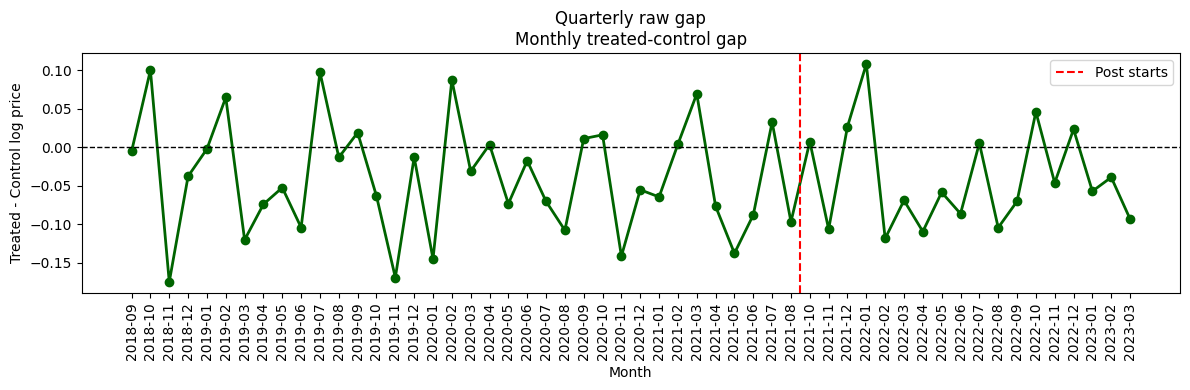

In [95]:
did_01x_new['year_quarter'] = did_01x_new['Date'].dt.to_period('Q').astype(str)
plot_monthly_log_price_and_gap(
    did_01x_new[
        (did_01x_new['treated'] == 1) |
        (
            (did_01x_new['treated'] == 0) &
            (did_01x_new['pre_num_normal_schools_1_2km'] > 0) &  #changed_for_normalschool
            (did_01x_new['pre_num_good_schools_0_1km'] == did_01x_new['post_num_good_schools_0_1km'])
        )
    ],
    title='Quarterly raw gap',
    date_col='Date',   # but aggregate by quarter not month
)

## Without clustering

In [363]:
did_01x_new.columns

Index(['month', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease',
       'address', 'year', 'latitude', 'longitude', 'geometry', 'Date',
       'num_nearby_malls', 'num_nearby_mrt', 'num_unique_mrt_lines',
       'num_schools_0_1km_polygon', 'num_schools_0_1km_xy',
       'num_schools_1_2km_polygon', 'num_schools_1_2km_xy',
       'num_good_schools_0_1km_polygon', 'num_good_schools_0_1km_xy',
       'num_good_schools_1_2km_polygon', 'num_good_schools_1_2km_xy', 'period',
       'post', 'pre_num_good_schools_0_1km', 'post_num_good_schools_0_1km',
       'pre_num_good_schools_1_2km', 'post_num_good_schools_1_2km',
       'pre_num_good_schools_0_2km', 'post_num_good_schools_0_2km',
       'pre_num_schools_0_1km', 'post_num_schools_0_1km',
       'pre_num_schools_1_2km', 'post_num_schools_1_2km',
       'pre_num_schools_0_2km', 'post_num_schools_0_2km',
       'pre_num_normal_schools_0_1km', 'post_num_norma

In [364]:
import warnings

threshold_grid = np.arange(500,3000,100)
results = []

for control_radius_m in threshold_grid:
    work_df = did_01x_new.copy()

    work_df = work_df[
        (work_df['treated'] == 1) |
        (
            (work_df['treated'] == 0)
        )
    ].copy()

    work_df['n_level'] = bucket_n_level(work_df['pre_num_normal_schools_0_1km'])
    work_df['flat_type_clean'] = clean_label(work_df['flat_type'])
    work_df['geometry'] = work_df['geometry'].apply(
        lambda g: wkt.loads(g) if isinstance(g, str) else g
    )

    work_gdf = gpd.GeoDataFrame(work_df, geometry='geometry', crs='EPSG:3414')

    local_parts = []

    for n_val in sorted(work_gdf['n_level'].dropna().unique()):
        gdf_n = work_gdf[work_gdf['n_level'] == n_val].copy()

        treated_n = gdf_n[gdf_n['treated'] == 1].copy()
        control_n = gdf_n[gdf_n['treated'] == 0].copy()

        if treated_n.empty or control_n.empty:
            continue

        treated_sites = treated_n[['geometry']].copy()
        treated_sites['treated_site_id'] = range(len(treated_sites))
        treated_sites = treated_sites.drop_duplicates(subset=['geometry']).reset_index(drop=True)
        treated_sites = gpd.GeoDataFrame(treated_sites, geometry='geometry', crs=gdf_n.crs)

        control_join = gpd.sjoin_nearest(
            control_n,
            treated_sites[['treated_site_id', 'geometry']],
            how='left',
            distance_col='dist_to_treated'
        )

        control_keep = control_join[
            control_join['dist_to_treated'] <= control_radius_m
        ].copy()

        local_parts.append(treated_n)
        local_parts.append(control_keep)

    did_local = pd.concat(local_parts, ignore_index=True)

    did_local['year_quarter'] = did_local['Date'].dt.to_period('Q').astype(str)
    did_local['log_price'] = np.log(did_local['resale_price'])

    did_local, cat_dummy_cols = add_categorical_dummies(
        did_local,
        ['n_level', 'pre_num_good_schools_1_2km_bin', 'flat_model', 'storey_range']
    )

    covariate_cols = [
        'floor_area_sqm',
        'remaining_lease',
        'num_unique_mrt_lines',
        'num_nearby_malls'
    ] + cat_dummy_cols

    did_local['unit_id'] = (
        did_local['treated'].astype(str)
        + '_g01_' + did_local['pre_num_good_schools_0_1km_bin'].astype(str)
        + '_ft_' + did_local['flat_type_clean']
    )

    agg_map = {
        'log_price': ('log_price', 'mean'),
        'floor_area_sqm': ('floor_area_sqm', 'mean'),
        'remaining_lease': ('remaining_lease', 'mean'),
        'num_unique_mrt_lines': ('num_unique_mrt_lines', 'mean'),
        'num_nearby_malls': ('num_nearby_malls', 'mean')
    }
    agg_map.update({col: (col, 'mean') for col in cat_dummy_cols})

    sdid_panel = (
        did_local
        .groupby(['unit_id', 'year_quarter'], as_index=False)
        .agg(**agg_map)
    )

    unit_meta = did_local[['unit_id', 'treated']].drop_duplicates()
    sdid_panel = sdid_panel.merge(unit_meta, on='unit_id', how='left')

    sdid_panel = balance_panel(
        sdid_panel,
        unit_column='unit_id',
        time_column='year_quarter',
        method='inner'
    )

    if sdid_panel.empty or sdid_panel['treated'].nunique() < 2:
        results.append({
            'control_radius_m': control_radius_m,
            'n_obs': len(did_local),
            'n_units': 0,
            'att': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        })
        continue

    sdid_panel['treated'] = (
        sdid_panel.groupby('unit_id')['treated']
        .transform('max')
        .astype(int)
    )

    post_periods = sorted(
        sdid_panel.loc[sdid_panel['year_quarter'] >= '2021Q4', 'year_quarter'].unique()
    )

    sdid = SyntheticDiD(
        seed=42,
        variance_method='placebo',
        n_bootstrap=500
    )

    pre_periods = sorted(
        sdid_panel.loc[sdid_panel['year_quarter'] < '2021Q4', 'year_quarter'].unique()
    )

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter('always')
        res = sdid.fit(
            sdid_panel,
            outcome='log_price',
            treatment='treated',
            unit='unit_id',
            time='year_quarter',
            post_periods=post_periods,
            covariates=covariate_cols
        )

    treated_pre = sdid_panel[
        (sdid_panel['treated'] == 1) &
        (sdid_panel['year_quarter'].isin(pre_periods))
    ]['log_price']
    treated_pre_sd = treated_pre.std()
    pre_fit_ratio = (
        res.pre_treatment_fit / treated_pre_sd
        if pd.notna(treated_pre_sd) and treated_pre_sd > 0
        else np.nan
    )
    poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
    poor_pre_fit = poor_pre_fit or any(
        'Pre-treatment fit is poor' in str(w.message)
        for w in caught_warnings
    )

    results.append({
        'control_radius_m': control_radius_m,
        'n_obs': len(did_local),
        'n_treated_obs': int((did_local['treated'] == 1).sum()),
        'n_control_obs': int((did_local['treated'] == 0).sum()),
        'n_units': sdid_panel['unit_id'].nunique(),
        'n_treated_units': sdid_panel.loc[sdid_panel['treated'] == 1, 'unit_id'].nunique(),
        'n_control_units': sdid_panel.loc[sdid_panel['treated'] == 0, 'unit_id'].nunique(),
        'att': res.att,
        'se': res.se,
        'p_value': res.p_value,
        'pre_fit_rmse': res.pre_treatment_fit,
        'poor_pre_fit': poor_pre_fit,
        'pre_fit_ratio': pre_fit_ratio,
    })

cv_df = pd.DataFrame(results)
display(cv_df.sort_values('control_radius_m'))

,control_radius_m,n_obs,n_treated_obs,n_control_obs,n_units,n_treated_units,n_control_units,att,se,p_value,pre_fit_rmse,poor_pre_fit,pre_fit_ratio
0,500,13245,2162,11083,9,4,5,-0.003157,0.018564,1.000,0.015769,True,0.044727
1,600,15035,2162,12873,9,4,5,-0.000221,0.020069,1.000,0.014264,True,0.040460
2,700,16832,2162,14670,9,4,5,-0.001376,0.021120,1.000,0.014630,True,0.041497
3,800,18633,2162,16471,9,4,5,-0.002304,0.020113,1.000,0.015341,True,0.043514
4,900,20257,2162,18095,9,4,5,-0.001641,0.018237,1.000,0.014778,True,0.041916
5,1000,21720,2162,19558,9,4,5,-0.002848,0.019127,1.000,0.015433,True,0.043775
6,1100,23136,2162,20974,9,4,5,-0.000995,0.019787,1.000,0.014970,True,0.042461
7,1200,24233,2162,22071,9,4,5,-0.011309,0.017911,0.586,0.015890,True,0.045069
8,1300,25089,2162,22927,9,4,5,-0.008330,0.018003,1.000,0.012340,True,0.035002
9,1400,25900,2162,23738,9,4,5,-0.006993,0.015495,1.000,0.012308,True,0.034911


In [5]:
from diff_diff import SyntheticDiD
from diff_diff.prep import balance_panel
from shapely import wkt
import geopandas as gpd
import pandas as pd
import numpy as np
import warnings

# -----------------------------------------------------------------------------
# No clustering: keep only relevant local controls
# treated: (0, n) -> (1, n)
# control: (0, n) -> (0, n)
# controls must be within control_radius_m of a treated point in the same n_level
# flat_type is part of unit_id
# -----------------------------------------------------------------------------

control_radius_m = 1300

work_df = did_01x_new.copy()

# donut logic
work_df = work_df[
    (work_df['treated'] == 1) |
    (
        (work_df['treated'] == 0) &
        (work_df['pre_num_normal_schools_1_2km'] > 0) #changed_for_normalschool ensure control points have at least 1 normal school in 1-2km, to avoid being too far from treated points
    )
].copy()

work_df['n_level'] = bucket_n_level(work_df['pre_num_normal_schools_0_1km'])
work_df['flat_type_clean'] = clean_label(work_df['flat_type'])

work_df['geometry'] = work_df['geometry'].apply(
    lambda g: wkt.loads(g) if isinstance(g, str) else g
)

work_gdf = gpd.GeoDataFrame(
    work_df,
    geometry='geometry',
    crs='EPSG:3414'
)

local_parts = []

for n_val in sorted(work_gdf['n_level'].dropna().unique()):
    gdf_n = work_gdf[work_gdf['n_level'] == n_val].copy()

    treated_n = gdf_n[gdf_n['treated'] == 1].copy()
    control_n = gdf_n[gdf_n['treated'] == 0].copy()

    if treated_n.empty or control_n.empty:
        continue

    treated_sites = treated_n[['geometry']].copy()
    treated_sites['treated_site_id'] = range(len(treated_sites))
    treated_sites = treated_sites.drop_duplicates(subset=['geometry']).reset_index(drop=True)

    treated_sites = gpd.GeoDataFrame(
        treated_sites,
        geometry='geometry',
        crs=gdf_n.crs
    )

    # assign controls to nearest treated point
    control_join = gpd.sjoin_nearest(
        control_n,
        treated_sites[['treated_site_id', 'geometry']],
        how='left',
        distance_col='dist_to_treated'
    )

    control_keep = control_join[
        control_join['dist_to_treated'] <= control_radius_m
    ].copy()

    local_parts.append(treated_n)
    local_parts.append(control_keep)

did_local = pd.concat(local_parts, ignore_index=True)

print("Sample size by treated / period:")
print(did_local.groupby(['treated', 'period']).size())

print("\nSample size by n_level / treated:")
print(did_local.groupby(['n_level', 'treated']).size())

# -----------------------------------------------------------------------------
# SDID panel
# flat_type is absorbed into unit_id
# flat_model and storey_range remain covariates
# -----------------------------------------------------------------------------

did_local['year_quarter'] = did_local['Date'].dt.to_period('Q').astype(str)
did_local['log_price'] = np.log(did_local['resale_price'])

did_local, cat_dummy_cols = add_categorical_dummies(
    did_local,
    ['n_level', 'pre_num_good_schools_1_2km_bin', 'flat_model', 'storey_range']
)

covariate_cols = [
    'floor_area_sqm',
    'remaining_lease',
] + cat_dummy_cols

did_local['unit_id'] = (
    did_local['treated'].astype(str)
    + '_g01_' + did_local['pre_num_good_schools_0_1km_bin'].astype(str)
    + '_ft_' + did_local['flat_type_clean']
)

agg_map = {
    'log_price': ('log_price', 'mean'),
    'floor_area_sqm': ('floor_area_sqm', 'mean'),
    'remaining_lease': ('remaining_lease', 'mean'),
}
agg_map.update({col: (col, 'mean') for col in cat_dummy_cols})

sdid_panel = (
    did_local
    .groupby(['unit_id', 'year_quarter'], as_index=False)
    .agg(**agg_map)
)

unit_meta = did_local[['unit_id', 'treated']].drop_duplicates()

sdid_panel = sdid_panel.merge(unit_meta, on='unit_id', how='left')

sdid_panel = balance_panel(
    sdid_panel,
    unit_column='unit_id',
    time_column='year_quarter',
    method='inner'
)

sdid_panel['treated'] = (
    sdid_panel.groupby('unit_id')['treated']
    .transform('max')
    .astype(int)
)

post_periods = sorted(
    sdid_panel.loc[sdid_panel['year_quarter'] >= '2021Q4', 'year_quarter'].unique()
)

print("\nBalanced SDID units:")
print(sdid_panel[['unit_id', 'treated']].drop_duplicates()['treated'].value_counts())

sdid = SyntheticDiD(
    seed=42,
    variance_method='placebo',
    n_bootstrap=500
)

pre_periods = sorted(
    sdid_panel.loc[sdid_panel['year_quarter'] < '2021Q4', 'year_quarter'].unique()
)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter('always')
    sdid_results = sdid.fit(
        sdid_panel,
        outcome='log_price',
        treatment='treated',
        unit='unit_id',
        time='year_quarter',
        post_periods=post_periods,
        covariates=covariate_cols
    )

treated_pre = sdid_panel[
    (sdid_panel['treated'] == 1) &
    (sdid_panel['year_quarter'].isin(pre_periods))
]['log_price']
treated_pre_sd = treated_pre.std()
pre_fit_ratio = (
    sdid_results.pre_treatment_fit / treated_pre_sd
    if pd.notna(treated_pre_sd) and treated_pre_sd > 0
    else np.nan
)
poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
poor_pre_fit = poor_pre_fit or any(
    'Pre-treatment fit is poor' in str(w.message)
    for w in caught_warnings
)

print(sdid_results.summary())
print(f'poor_pre_fit: {poor_pre_fit}')
print(f'pre_fit_ratio: {pre_fit_ratio:.4f}' if pd.notna(pre_fit_ratio) else 'pre_fit_ratio: nan')
display(sdid_results.get_unit_weights_df())
display(sdid_results.get_time_weights_df())


Sample size by treated / period:
treated  period
0        post      22874
         pre       39604
1        post       9328
         pre       17204
dtype: int64

Sample size by n_level / treated:
n_level  treated
0        0           2832
         1            860
1        0           8520
         1           4736
2plus    0          51126
         1          20936
dtype: int64

Balanced SDID units:
treated
0    12
1    10
Name: count, dtype: int64
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    418
Treated:                          10
Control:                          12
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.0815
Zeta (time weights):        0.000000
Noise level:                  0.0293
Pre-treatment fit (RMSE):     0.0087
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           E

,unit,weight
2,0_g01_0_ft_4_ROOM,0.095929
3,0_g01_0_ft_5_ROOM,0.094697
9,0_g01_1_ft_EXECUTIVE,0.092447
4,0_g01_0_ft_EXECUTIVE,0.086148
6,0_g01_1_ft_3_ROOM,0.085973
8,0_g01_1_ft_5_ROOM,0.085163
7,0_g01_1_ft_4_ROOM,0.084496
1,0_g01_0_ft_3_ROOM,0.081284
0,0_g01_0_ft_2_ROOM,0.076970
5,0_g01_1_ft_2_ROOM,0.075997


,period,weight
0,2018Q3,0.000000
1,2018Q4,0.004058
2,2019Q1,0.130853
3,2019Q2,0.134186
4,2019Q3,0.000000
5,2019Q4,0.155364
6,2020Q1,0.000000
7,2020Q2,0.000000
8,2020Q3,0.000000
9,2020Q4,0.394844


In [6]:
plot_monthly_log_price_and_gap(
    sdid_df_nc,
    title='Non-clustered clean baseline'
)

NameError: name 'sdid_df_nc' is not defined

### Original DiD setup with covariates, but without clustering (i.e. just a single control group)

In [7]:
import numpy as np
import statsmodels.formula.api as smf

# -----------------------------------------------------------------------------
# Plain DiD: non-clustered clean baseline
# Compare within n_level x flat_type strata
# -----------------------------------------------------------------------------

did_df_nc = did_01x_new.copy()

did_df_nc = did_df_nc[
    (did_df_nc['treated'] == 1) |
    (
        (did_df_nc['treated'] == 0) &
        (did_df_nc['pre_num_normal_schools_1_2km'] > 0)  #changed_for_normalschool
    )
].copy()

did_df_nc['log_price'] = np.log(did_df_nc['resale_price'])
did_df_nc['year_quarter'] = did_df_nc['Date'].dt.to_period('Q').astype(str)
did_df_nc['n_level'] = did_df_nc['pre_num_normal_schools_0_1km'].astype(int)

did_df_nc['stratum_id'] = (
    'n' + did_df_nc['n_level'].astype(str)
    + '_ft_' + did_df_nc['flat_type'].astype(str)
)

did_model_nc = smf.ols(
    """
    log_price ~ treated * post
    + C(year_quarter)
    + C(stratum_id)
    + floor_area_sqm
    + remaining_lease
    + num_nearby_mrt
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """,
    data=did_df_nc
).fit(
    cov_type='cluster',
    cov_kwds={'groups': did_df_nc['stratum_id']}
)

print("Non-clustered DiD ATT (treated:post):")
print(did_model_nc.params['treated:post'])
print(did_model_nc.bse['treated:post'])
print(did_model_nc.pvalues['treated:post'])
print(did_model_nc.summary())

Non-clustered DiD ATT (treated:post):
-0.0073937118807903875
0.0035024776411424624
0.03477276389606408
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                 1.178e+07
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          6.99e-167
Time:                        14:55:07   Log-Likelihood:                 42496.
No. Observations:               90835   AIC:                        -8.477e+04
Df Residuals:                   90723   BIC:                        -8.371e+04
Df Model:                         111                                         
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 113, but rank is 50
  warnings.warn('covariance of constraints does not have full '


In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# -----------------------------------------------------------------------------
# Pre-trends test
# H0: all treated x pre-quarter interaction terms = 0
# -----------------------------------------------------------------------------

pre_df = did_df_nc[did_df_nc["post"] == 0].copy()

# Safe to recompute in case this cell is run standalone
pre_df["log_price"] = np.log(pre_df["resale_price"])
pre_df["year_quarter"] = pre_df["Date"].dt.to_period("Q").astype(str)
pre_df["n_level"] = pre_df["pre_num_normal_schools_0_1km"].astype(int)
pre_df["stratum_id"] = (
    "n" + pre_df["n_level"].astype(str)
    + "_ft_" + pre_df["flat_type"].astype(str)
)

pre_quarters = sorted(pre_df["year_quarter"].unique())
if len(pre_quarters) < 2:
    raise ValueError("Need at least 2 pre-treatment quarters to run a pre-trends test.")

ref_q = pre_quarters[-1]  # last pre-policy quarter as reference

pt_model = smf.ols(
    f"""
    log_price ~ treated
    + C(year_quarter, Treatment(reference='{ref_q}'))
    + treated:C(year_quarter, Treatment(reference='{ref_q}'))
    + C(stratum_id)
    + floor_area_sqm
    + remaining_lease
    + num_nearby_mrt
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """,
    data=pre_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": pre_df["stratum_id"]}
)

# All treated x pre-quarter coefficients
pt_terms = [
    t for t in pt_model.params.index
    if "treated:C(year_quarter" in t
]

if len(pt_terms) == 0:
    raise ValueError("No pre-period interaction terms were generated.")

# Joint test: all pre-period interaction coefficients = 0
R = np.zeros((len(pt_terms), len(pt_model.params)))
for i, term in enumerate(pt_terms):
    R[i, pt_model.params.index.get_loc(term)] = 1

joint_test = pt_model.f_test(R)

pretrend_table = pd.DataFrame({
    "term": pt_terms,
    "coef": pt_model.params[pt_terms].values,
    "se": pt_model.bse[pt_terms].values,
    "pvalue": pt_model.pvalues[pt_terms].values,
})

print(f"Reference pre-period: {ref_q}")
print("\nPre-trend coefficients:")
print(pretrend_table)

print("\nJoint test of parallel pre-trends:")
print(f"F-stat: {float(np.asarray(joint_test.fvalue).squeeze()):.4f}")
print(f"p-value: {float(np.asarray(joint_test.pvalue).squeeze()):.4f}")

Reference pre-period: 2021Q3

Pre-trend coefficients:
                                                 term      coef        se  \
0   treated:C(year_quarter, Treatment(reference='2... -0.004845  0.014281   
1   treated:C(year_quarter, Treatment(reference='2...  0.016835  0.009585   
2   treated:C(year_quarter, Treatment(reference='2...  0.008580  0.010259   
3   treated:C(year_quarter, Treatment(reference='2...  0.022018  0.009445   
4   treated:C(year_quarter, Treatment(reference='2...  0.020979  0.007910   
5   treated:C(year_quarter, Treatment(reference='2...  0.010419  0.009333   
6   treated:C(year_quarter, Treatment(reference='2...  0.013881  0.009109   
7   treated:C(year_quarter, Treatment(reference='2...  0.009355  0.008635   
8   treated:C(year_quarter, Treatment(reference='2...  0.005005  0.009559   
9   treated:C(year_quarter, Treatment(reference='2...  0.002025  0.007764   
10  treated:C(year_quarter, Treatment(reference='2... -0.004776  0.006636   
11  treated:C(year_qua